# Power Outages Analysis

**Name(s)**: Ahyo Falick

**Website Link**: (your website link)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc259r_utils import * # Feel free to uncomment and use this.

In [29]:
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"

In [71]:
df = pd.read_csv('outage.csv', skiprows=5)
df = df.drop('variables', axis=1)
df = df.iloc[1:]

## Step 1: Introduction
#### Understand the data you have access to. Brainstorm a few questions that interest you about the dataset. Pick one question you plan to investigate further. (As the data science lifecycle tells us, this question may change as you work on your project.)

### Questions
* Where and when do major power outages tend to occur?
* What are the characteristics of major power outages with higher severity? Variables to consider include location, time, climate, land-use characteristics, electricity consumption patterns, economic characteristics, etc.
* What risk factors may an energy company want to look into when predicting the location and severity of its next major power outage?
* What characteristics are associated with each category of cause?
* How have characteristics of major power outages changed over time? Is there a clear trend?

### Question to investigate further:
**What are the characteristics of major power outages with higher severity? Variables to consider include location, time, climate, land-use characteristics, electricity consumption patterns, economic characteristics, etc.**

## Step 2: Data Cleaning and Exploratory Data Analysis

### Data Cleaning:
#### Clean the data appropriately. For instance, you may need to replace data that should be missing with NaN or create new columns out of given ones (e.g. compute distances, scale data, or get time information from time stamps).

In [98]:
df.columns

Index(['OBS', 'YEAR', 'MONTH', 'U.S._STATE', 'POSTAL.CODE', 'NERC.REGION',
       'CLIMATE.REGION', 'ANOMALY.LEVEL', 'CLIMATE.CATEGORY',
       'OUTAGE.START.DATE', 'OUTAGE.START.TIME', 'OUTAGE.RESTORATION.DATE',
       'OUTAGE.RESTORATION.TIME', 'CAUSE.CATEGORY', 'CAUSE.CATEGORY.DETAIL',
       'HURRICANE.NAMES', 'OUTAGE.DURATION', 'DEMAND.LOSS.MW',
       'CUSTOMERS.AFFECTED', 'RES.PRICE', 'COM.PRICE', 'IND.PRICE',
       'TOTAL.PRICE', 'RES.SALES', 'COM.SALES', 'IND.SALES', 'TOTAL.SALES',
       'RES.PERCEN', 'COM.PERCEN', 'IND.PERCEN', 'RES.CUSTOMERS',
       'COM.CUSTOMERS', 'IND.CUSTOMERS', 'TOTAL.CUSTOMERS', 'RES.CUST.PCT',
       'COM.CUST.PCT', 'IND.CUST.PCT', 'PC.REALGSP.STATE', 'PC.REALGSP.USA',
       'PC.REALGSP.REL', 'PC.REALGSP.CHANGE', 'UTIL.REALGSP', 'TOTAL.REALGSP',
       'UTIL.CONTRI', 'PI.UTIL.OFUSA', 'POPULATION', 'POPPCT_URBAN',
       'POPPCT_UC', 'POPDEN_URBAN', 'POPDEN_UC', 'POPDEN_RURAL',
       'AREAPCT_URBAN', 'AREAPCT_UC', 'PCT_LAND', 'PCT_WATER_TOT',
    

In [4]:
na_cols = df.isna().sum()
na_cols[na_cols > 0].index

Index(['MONTH', 'CLIMATE.REGION', 'ANOMALY.LEVEL', 'CLIMATE.CATEGORY',
       'OUTAGE.START.DATE', 'OUTAGE.START.TIME', 'OUTAGE.RESTORATION.DATE',
       'OUTAGE.RESTORATION.TIME', 'CAUSE.CATEGORY.DETAIL', 'HURRICANE.NAMES',
       'OUTAGE.DURATION', 'DEMAND.LOSS.MW', 'CUSTOMERS.AFFECTED', 'RES.PRICE',
       'COM.PRICE', 'IND.PRICE', 'TOTAL.PRICE', 'RES.SALES', 'COM.SALES',
       'IND.SALES', 'TOTAL.SALES', 'RES.PERCEN', 'COM.PERCEN', 'IND.PERCEN',
       'POPDEN_UC', 'POPDEN_RURAL'],
      dtype='object')

In [5]:
df.dtypes

OBS                 float64
YEAR                float64
MONTH               float64
                     ...   
PCT_LAND             object
PCT_WATER_TOT        object
PCT_WATER_INLAND     object
Length: 56, dtype: object

### Univariate Analysis:
#### Look at the distributions of relevant columns separately by using DataFrame operations and drawing at least two relevant plots.

In [90]:
def plot_value_counts(counts, labels, r, size):
    plt.bar(counts.index, counts)
    plt.ylabel("Counts")
    plt.xticks(counts.index, labels, rotation=r)
    plt.rcParams['xtick.labelsize'] = size
    plt.show()

In [91]:
import calendar

In [92]:
dates = pd.to_datetime(df['OUTAGE.START.DATE'])
year_counts = df['YEAR'].dropna().astype('int64').value_counts()
month_counts = df['MONTH'].dropna().astype('int64').value_counts().sort_index()
category_counts = df['CAUSE.CATEGORY'].dropna().value_counts()

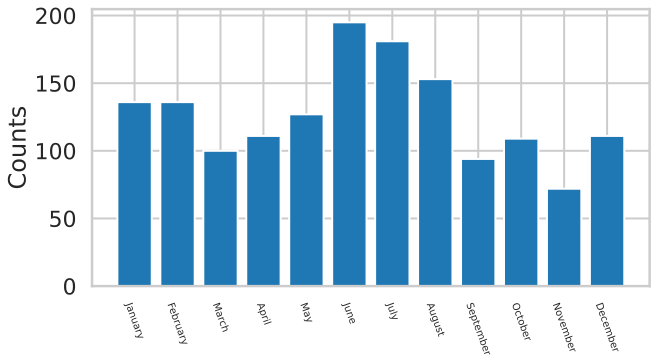

In [93]:
plot_value_counts(month_counts, [calendar.month_name[x] for x in month_counts.index.values], -70, 10)

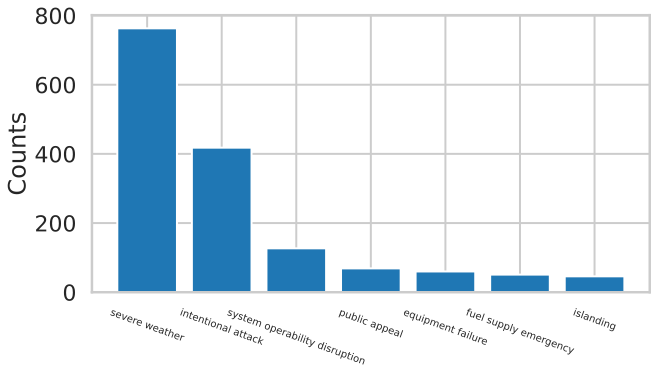

In [94]:
plot_value_counts(category_counts, category_counts.index.values, -20, 10)

### Bivariate Analysis:
#### Look at the statistics of pairs of columns to identify possible associations. For instance, you may create scatter plots and plot conditional distributions, or box-plots. You must plot at least two such plots in your notebook. The results of your bivariate analyses will be helpful in identifying interesting hypothesis tests!

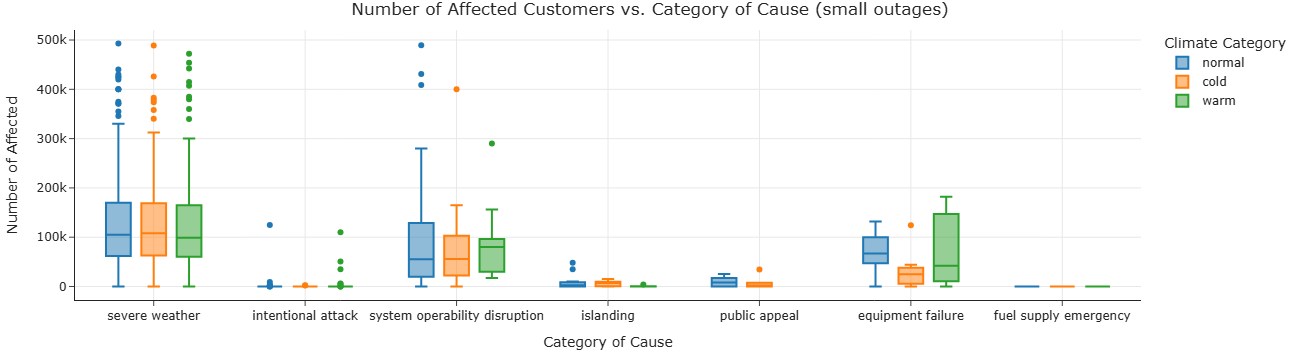

In [95]:
df2 = df[df['CUSTOMERS.AFFECTED'] < 500000][['CAUSE.CATEGORY', 'CUSTOMERS.AFFECTED', 'CLIMATE.CATEGORY']].dropna()
fig = px.box(df2, title="Number of Affected Customers vs. Category of Cause (small outages)", x="CAUSE.CATEGORY", y="CUSTOMERS.AFFECTED", color="CLIMATE.CATEGORY",
            labels={"CAUSE.CATEGORY": "Category of Cause", "CUSTOMERS.AFFECTED": "Number of Affected", "CLIMATE.CATEGORY": "Climate Category"})
            #color_discrete_sequence=['orange', 'blue'])
fig.show()

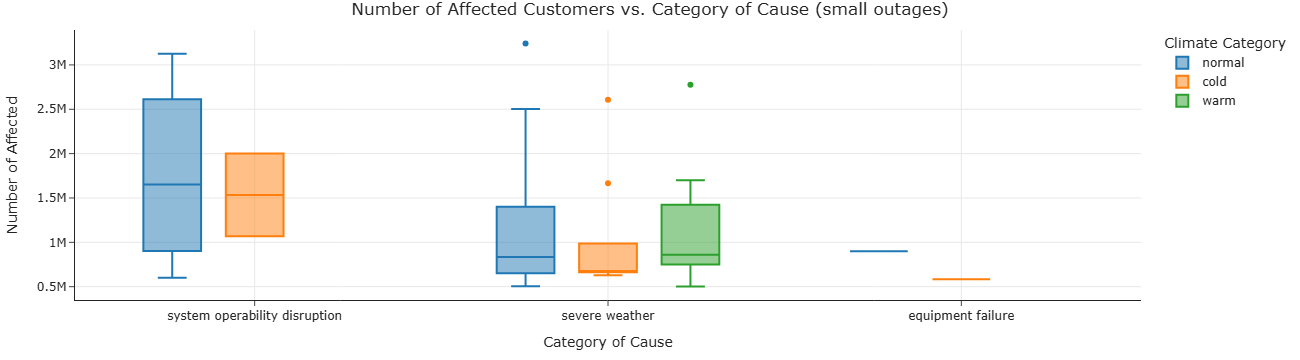

In [69]:
df3 = df[df['CUSTOMERS.AFFECTED'] > 500000][['CAUSE.CATEGORY', 'CUSTOMERS.AFFECTED', 'CLIMATE.CATEGORY']].dropna()
fig = px.box(df3, title="Number of Affected Customers vs. Category of Cause (small outages)", x="CAUSE.CATEGORY", y="CUSTOMERS.AFFECTED", color="CLIMATE.CATEGORY",
            labels={"CAUSE.CATEGORY": "Category of Cause", "CUSTOMERS.AFFECTED": "Number of Affected", "CLIMATE.CATEGORY": "Climate Category"})
            #color_discrete_sequence=['orange', 'blue'])
fig.show()

### Interesting Aggregates:
#### Choose columns to group and pivot by and examine aggregate statistics.

In [3]:
# TODO

## Step 3: Assessment of Missingness

In [4]:
# TODO

## Step 4: Hypothesis Testing

In [5]:
# TODO

## Step 5: Framing a Prediction Problem

In [6]:
# TODO

## Step 6: Baseline Model

In [7]:
# TODO

## Step 7: Final Model

In [8]:
# TODO

## Step 8: Fairness Analysis

In [9]:
# TODO